İlk 5 satır:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      

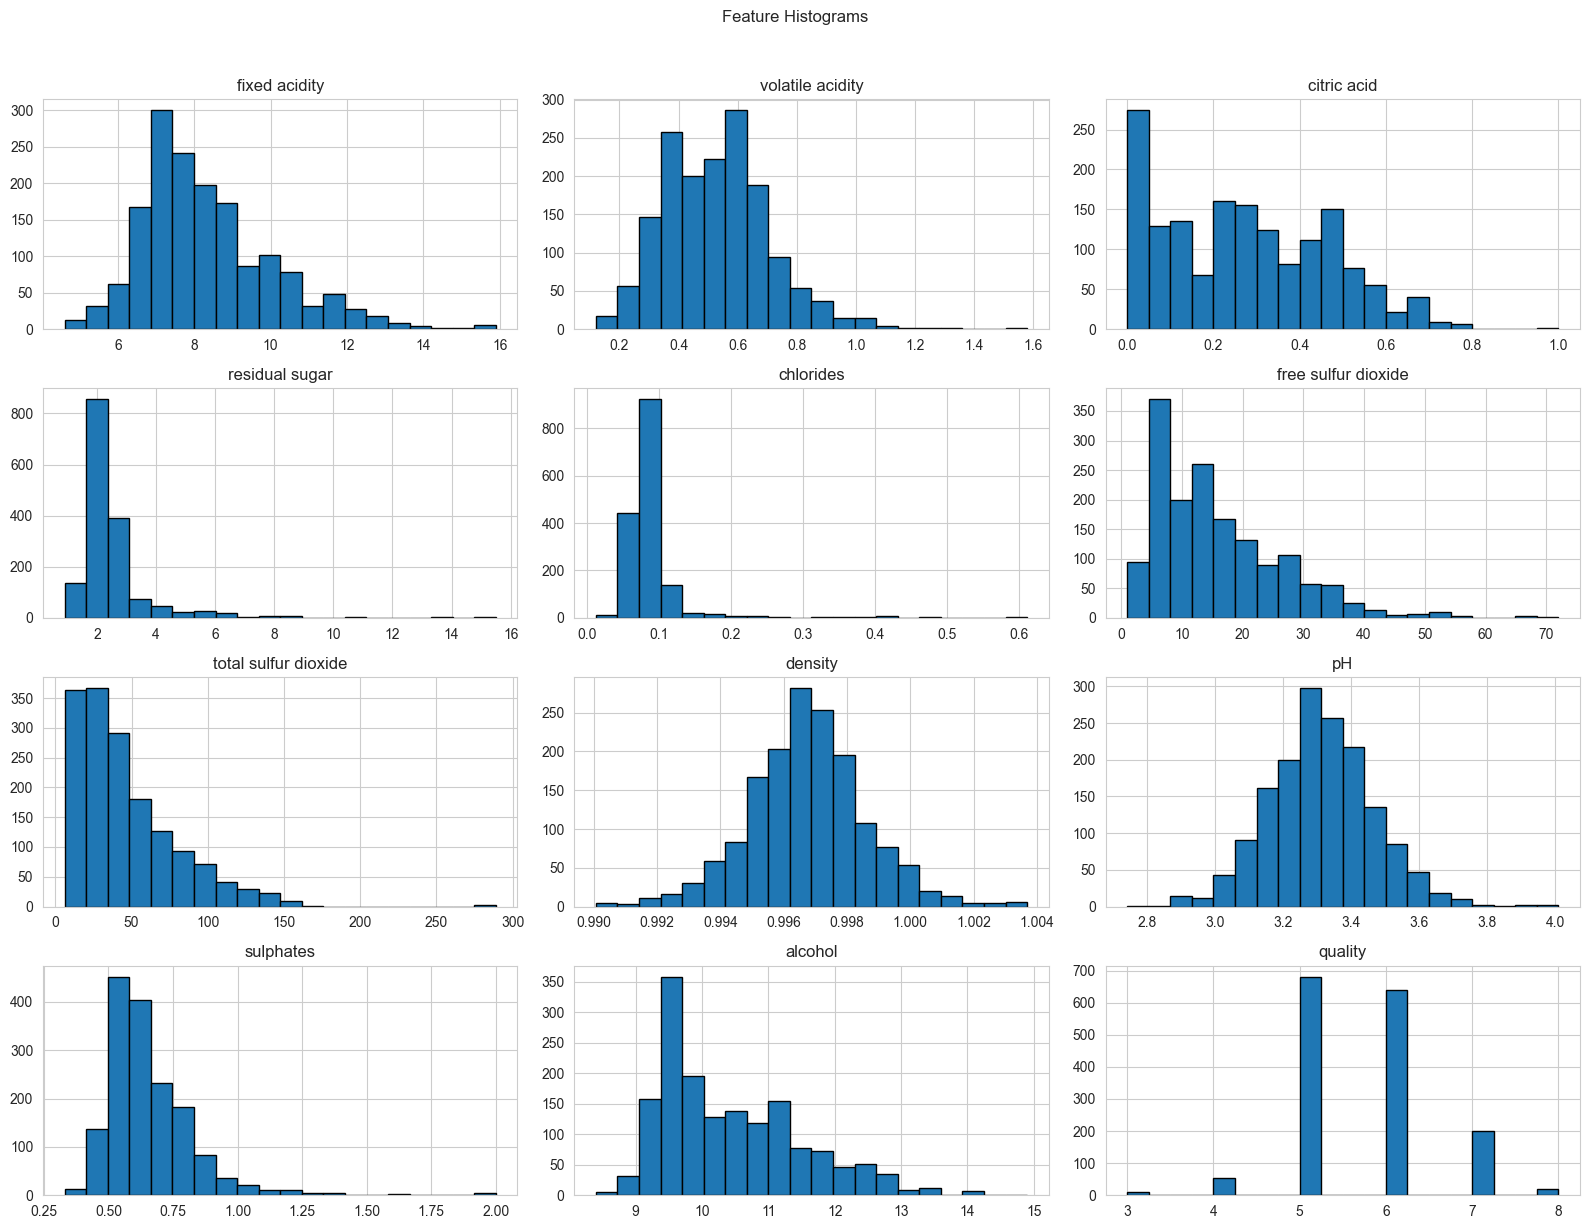


Sınıf dağılımı:
quality_label
low       744
medium    638
high      217
Name: count, dtype: int64

Kod eşlemesi:
{0: 'low', 1: 'medium', 2: 'high'}

Train set boyutu: (1279, 11)
Test set boyutu: (320, 11)

Explained variance ratio:
[0.2800267  0.17093915]
Toplam açıklanan varyans: 0.45096584946739793


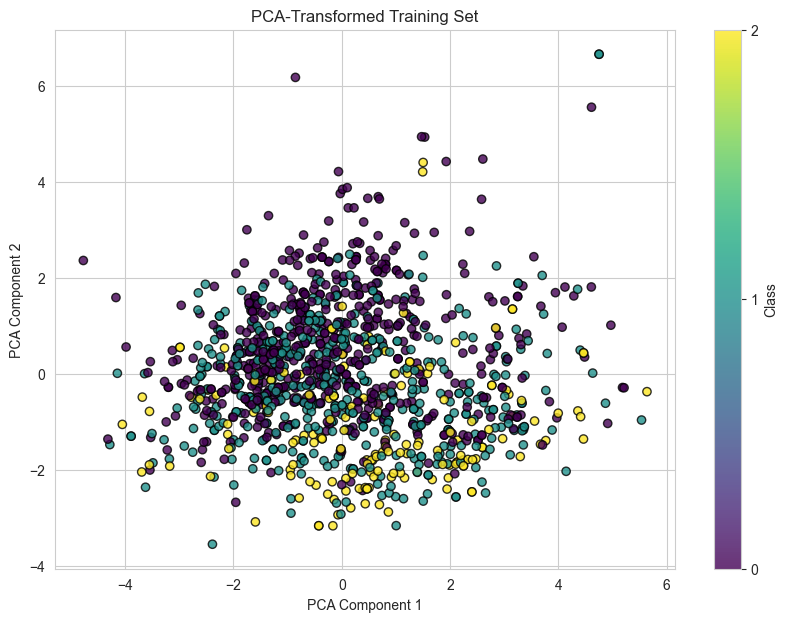


Random Forest Accuracy: 0.5594

KNN Accuracy: 0.4969

Logistic Regression Accuracy: 0.5750

En iyi performans gösteren model: Logistic Regression (0.5750)

Random Forest
Accuracy: 0.5594
Confusion Matrix:
[[113  33   3]
 [ 70  48  10]
 [  9  16  18]]
Classification Report:
              precision    recall  f1-score   support

         low       0.59      0.76      0.66       149
      medium       0.49      0.38      0.43       128
        high       0.58      0.42      0.49        43

    accuracy                           0.56       320
   macro avg       0.55      0.52      0.53       320
weighted avg       0.55      0.56      0.54       320


KNN
Accuracy: 0.4969
Confusion Matrix:
[[95 47  7]
 [63 46 19]
 [15 10 18]]
Classification Report:
              precision    recall  f1-score   support

         low       0.55      0.64      0.59       149
      medium       0.45      0.36      0.40       128
        high       0.41      0.42      0.41        43

    accuracy              

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split  #
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Soru 1: Veriyi yükle ve inceleme kısmım 
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')   # Veri setini okuyup df adlı DataFrame içine alıyorum.

print("İlk 5 satır:")
print(df.head())
print()
print(f"Örnek sayısı: {df.shape[0]}") # 
print(f"Özellik sayısı: {df.shape[1]}")
print()
print("Özet istatistikler:")
print(df.describe())
print()
print("Eksik değerler:")
print(df.isnull().sum())

print()
print("Histogramlar:")
df.hist(bins=20, figsize=(16, 12), edgecolor='black') #  grafiği 20 parçaya ayırıp kenarlarını siayh yapıyorum.
plt.suptitle("Feature Histograms", y=1.02)
plt.tight_layout()# grafiklerin üst üste binmesini engelliyor.
plt.show()

# Soru 2: ekdik değerleri çıkartıyor 

def quality_label(q): # burda fonksiyonu tanımladık asağıdada kategorize ediyorum
    if 3 <= q <= 5:
        return "low"
    elif q == 6:
        return "medium"
    elif 7 <= q <= 8:
        return "high"
    else:
        return np.nan

df['quality_label'] = df['quality'].apply(quality_label) # apply ile fonksionun tüm satırlarına uyguluyorum.
df = df.dropna(subset=['quality_label']).copy() #  boşi labelları siliyorum burda
df['quality_label'] = pd.Categorical(df['quality_label'], categories=['low', 'medium', 'high'], ordered=True)

X = df.drop(['quality', 'quality_label'], axis=1) # yeni giriş verileri
y_labels = df['quality_label'] #  y tahmin etmek istediğim hedeflerim 

y = y_labels.cat.codes # sayıya çeviriyoruz yazıları  
print("\nSınıf dağılımı:")
print(y_labels.value_counts())
print("\nKod eşlemesi:")
print(dict(enumerate(y_labels.cat.categories)))

# Soru 3: Train-test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain set boyutu:", X_train.shape)
print("Test set boyutu:", X_test.shape)

# Soru 4: Feature scaling y (tüm özellikleri benzer haldeki ölçeklere getiriyorum)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Soru 5: PCA ile boyut indirgeme,Çok sayıdaki özelliği daha az bileşene indirgeme yapıyoruz
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)
print("Toplam açıklanan varyans:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    cmap='viridis',
    alpha=0.8,
    edgecolor='k'
)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA-Transformed Training Set')
plt.colorbar(scatter, ticks=[0, 1, 2], label='Class')
plt.show()

# Soru 6: Sınıflandırma modellerini eğit ve karşılaştır
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    trained_models[name] = (model, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")

best_model_name = max(results, key=results.get)
print(f"\nEn iyi performans gösteren model: {best_model_name} ({results[best_model_name]:.4f})")

# Soru 7: Model değerlendirme yani modeli performansını detraylı analiz ediyorum. 
class_names = ['low', 'medium', 'high']

for name, (model, y_pred) in trained_models.items():
    print(f"\n{'=' * 60}")
    print(f"{name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))